# Medical RE Benchmark — Results Analysis

Visualizes and compares results from medre-bench experiments, including ROC-AUC.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

# RESULTS_DIR = Path("../outputs")
RESULTS_DIR = Path("/Users/basel.alshaikhdeeb/Documents/outputs2")

In [2]:
def collect_results(results_dir: Path) -> pd.DataFrame:
    """Collect all metrics.json files into a DataFrame, including ROC-AUC."""
    records = []
    for metrics_file in results_dir.rglob("metrics.json"):
        with open(metrics_file) as f:
            data = json.load(f)
        config = data.get("config", {})
        eval_m = data.get("eval", {})

        def pick(*keys):
            for k in keys:
                if k in eval_m and eval_m[k] is not None:
                    return eval_m[k]
            return None

        records.append({
            "model": config.get("model", "unknown"),
            "dataset": config.get("dataset", "unknown"),
            "seed": config.get("seed", 0),
            "micro_f1": pick("eval_micro_f1", "micro_f1"),
            "macro_f1": pick("eval_macro_f1", "macro_f1"),
            "weighted_f1": pick("eval_weighted_f1", "weighted_f1"),
            "accuracy": pick("eval_accuracy", "accuracy"),
            # Binary AUC
            "roc_auc": pick("eval_roc_auc", "roc_auc"),
            # Multi-class one-vs-rest
            "roc_auc_macro": pick("eval_roc_auc_macro", "roc_auc_macro"),
            "roc_auc_weighted": pick("eval_roc_auc_weighted", "roc_auc_weighted"),
        })
    df = pd.DataFrame(records)
    # Unify AUC into a single column for plotting (binary -> roc_auc, else macro)
    df["auc"] = df["roc_auc_macro"].combine_first(df["roc_auc"])
    return df

df = collect_results(RESULTS_DIR)
print(f"Found {len(df)} experiment runs")
df.sort_values("dataset")

Found 642 experiment runs


,model,dataset,seed,micro_f1,macro_f1,weighted_f1,accuracy,roc_auc,roc_auc_macro,roc_auc_weighted,auc
320,biobert,bc5cdr,456,0.950845,0.845681,0.950845,0.950845,0.975242,NaN,NaN,0.975242
85,pubmedbert,bc5cdr,7919,0.953419,0.856374,0.953834,0.953419,0.977732,NaN,NaN,0.977732
84,bert-base,bc5cdr,7919,0.943467,0.818058,0.942755,0.943467,0.971600,NaN,NaN,0.971600
529,bert-base,bc5cdr,2024,0.944197,0.820281,0.943473,0.944197,0.971891,NaN,NaN,0.971891
527,gatortron,bc5cdr,456,0.951917,0.853306,0.952593,0.951917,0.977854,NaN,NaN,0.977854
...,...,...,...,...,...,...,...,...,...,...,...
283,pubmedbert-large,gad,42,0.808067,0.807796,0.807866,0.808067,0.878041,NaN,NaN,0.878041
278,gpt2,gad,123,0.764951,0.763517,0.763696,0.764951,0.842538,NaN,NaN,0.842538
561,scibert,gad,42,0.799722,0.799582,0.799633,0.799722,0.863590,NaN,NaN,0.863590
301,clinicalbert,gad,42,0.764951,0.763190,0.763389,0.764951,0.831329,NaN,NaN,0.831329


## 1. Pivot Tables — F1 and AUC

In [3]:
micro_pivot = df.pivot_table(index="model", columns="dataset", values="micro_f1", aggfunc="mean")
macro_pivot = df.pivot_table(index="model", columns="dataset", values="macro_f1", aggfunc="mean")
auc_pivot = df.pivot_table(index="model", columns="dataset", values="auc", aggfunc="mean")

print("=== Micro F1 ===")
print(micro_pivot.round(3).to_string())
print("\n=== Macro F1 ===")
print(macro_pivot.round(3).to_string())
print("\n=== ROC-AUC (binary or macro one-vs-rest) ===")
print(auc_pivot.round(3).to_string())

=== Micro F1 ===
dataset            bc5cdr  biored  chem_dis_gene  chemprot    ddi  drugprot  euadr    gad
model                                                                                    
bert-base           0.944   0.772          0.978     0.965  0.981     0.960  0.943  0.759
bio-clinicalbert    0.944   0.774          0.977     0.965  0.981     0.960  0.948  0.754
biobert             0.950   0.785          0.981     0.968  0.983     0.962  0.950  0.798
biogpt              0.948   0.779          0.980     0.964  0.981     0.945  0.957  0.774
biolinkbert-base    0.954   0.792          0.981     0.970  0.984     0.959  0.954  0.794
biolinkbert-large   0.956   0.791          0.983     0.777  0.985     0.004  0.957  0.811
biomed-roberta      0.950   0.787          0.980     0.967  0.983     0.963  0.949  0.800
clinicalbert        0.944   0.773          0.977     0.965  0.980     0.960  0.947  0.760
gatortron           0.953   0.790          0.982     0.969  0.984     0.958  0.954 

## 2. Heatmaps

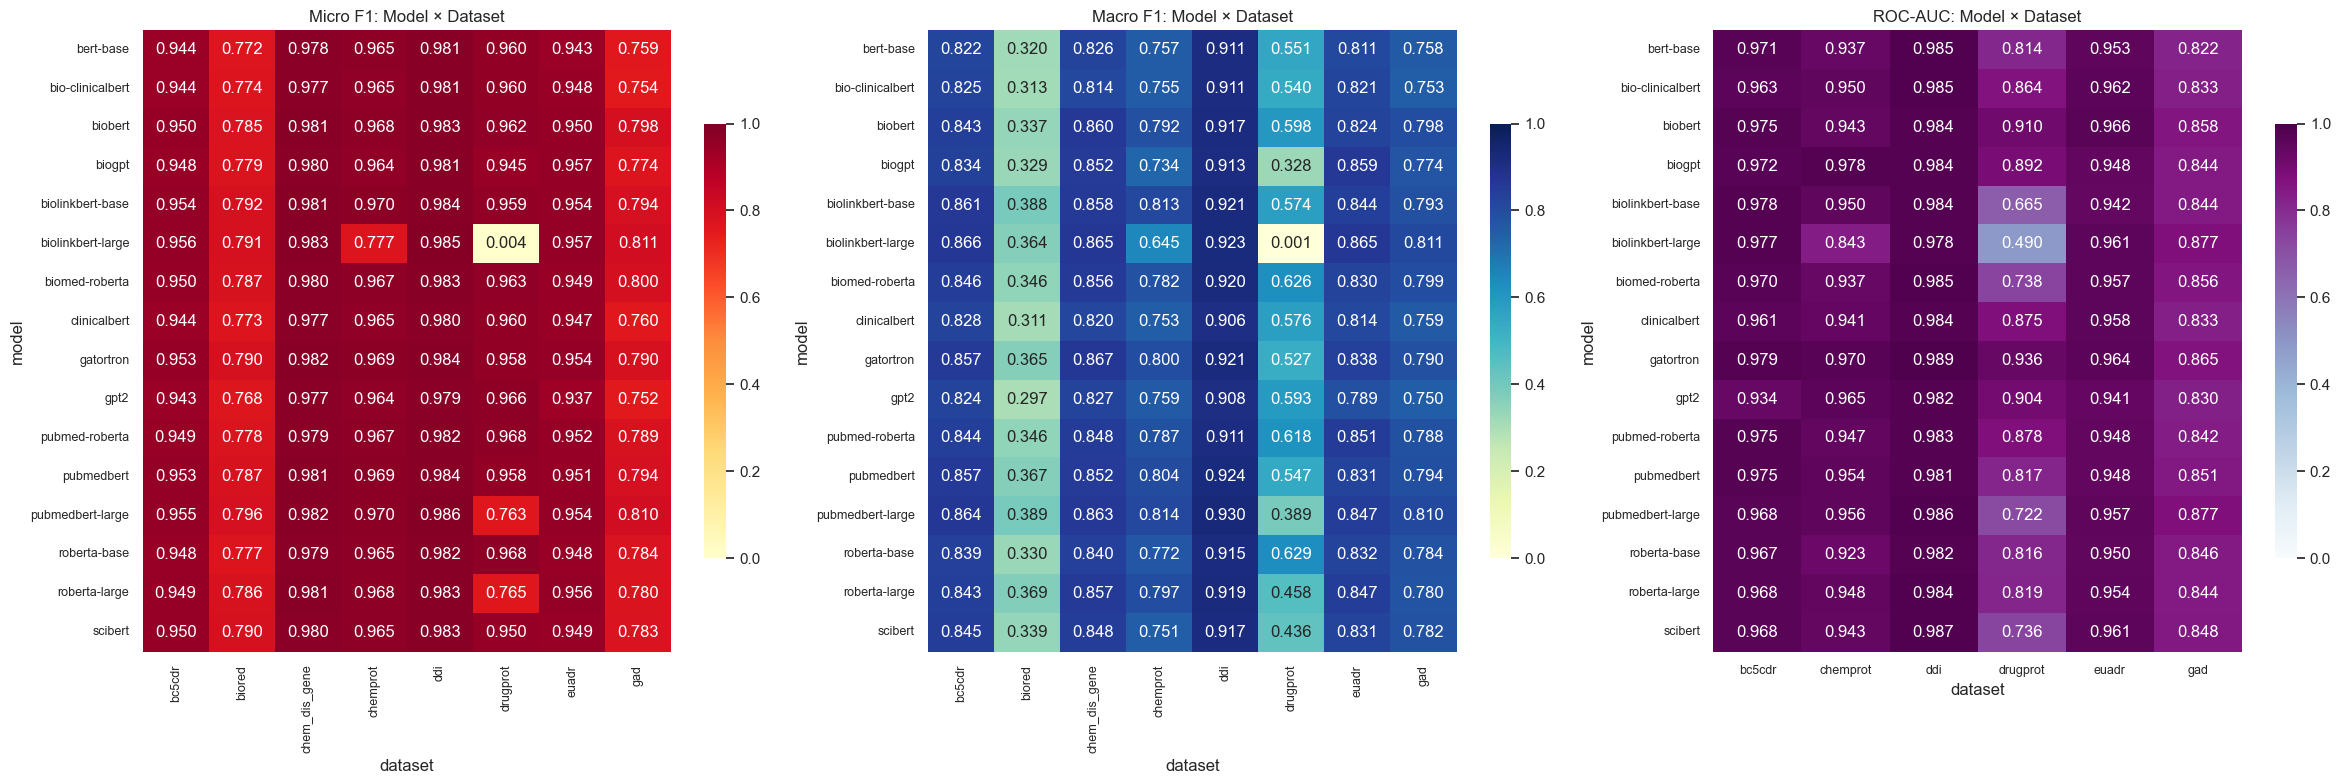

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

for ax, (title, pivot, cmap) in zip(
    axes,
    [
        ("Micro F1", micro_pivot, "YlOrRd"),
        ("Macro F1", macro_pivot, "YlGnBu"),
        ("ROC-AUC", auc_pivot, "BuPu"),
    ],
):
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap=cmap, ax=ax, vmin=0, vmax=1, cbar_kws={"shrink": 0.7})
    ax.set_title(f"{title}: Model × Dataset")
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=9)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=9)

plt.tight_layout()
plt.savefig("metrics_heatmap.png", dpi=150)
plt.show()

## 3. Per-Dataset Comparison (Micro F1, Macro F1, ROC-AUC)

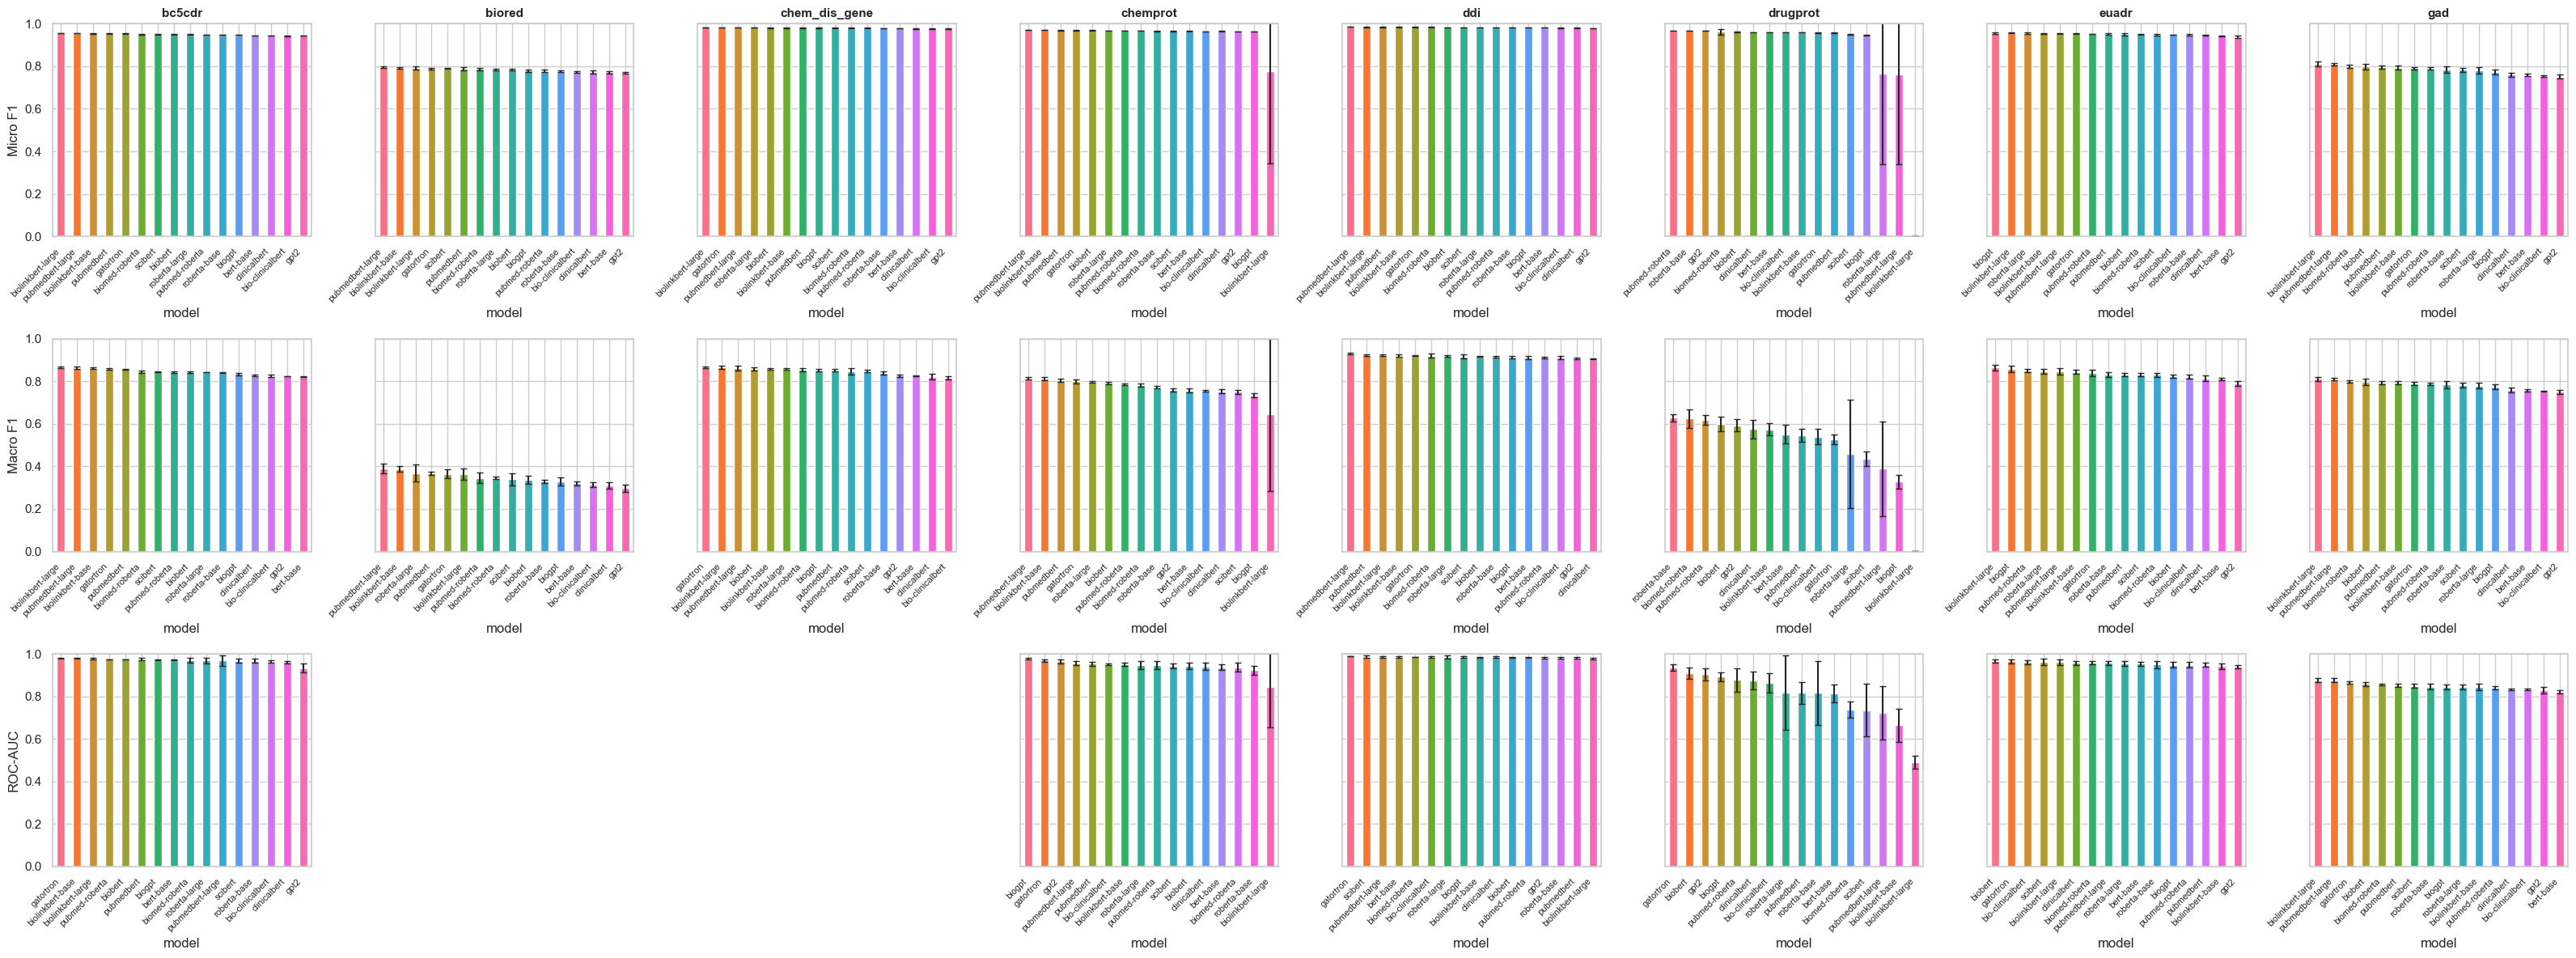

In [4]:
datasets_sorted = sorted(df["dataset"].unique())
metrics_to_plot = [
    ("micro_f1", "Micro F1"),
    ("macro_f1", "Macro F1"),
    ("auc", "ROC-AUC"),
]

fig, axes = plt.subplots(
    len(metrics_to_plot), len(datasets_sorted),
    figsize=(4 * len(datasets_sorted), 4 * len(metrics_to_plot)),
    sharey="row",
)

for row_idx, (metric_key, metric_label) in enumerate(metrics_to_plot):
    for col_idx, dataset in enumerate(datasets_sorted):
        ax = axes[row_idx, col_idx]
        subset = df[df["dataset"] == dataset]
        means = subset.groupby("model")[metric_key].mean().dropna().sort_values(ascending=False)
        if means.empty:
            ax.set_visible(False)
            continue
        stds = subset.groupby("model")[metric_key].std().reindex(means.index).fillna(0)

        means.plot(
            kind="bar", ax=ax, yerr=stds, capsize=3,
            color=sns.color_palette("husl", len(means)),
        )
        if row_idx == 0:
            ax.set_title(dataset, fontsize=11, fontweight="bold")
        if col_idx == 0:
            ax.set_ylabel(metric_label)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
        ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig("per_dataset_comparison.png", dpi=150)
plt.show()

## 4. Macro F1 vs ROC-AUC

Macro F1 punishes minority-class errors hard; ROC-AUC measures ranking quality regardless of decision threshold. Big gaps between the two suggest threshold-tuning could help.

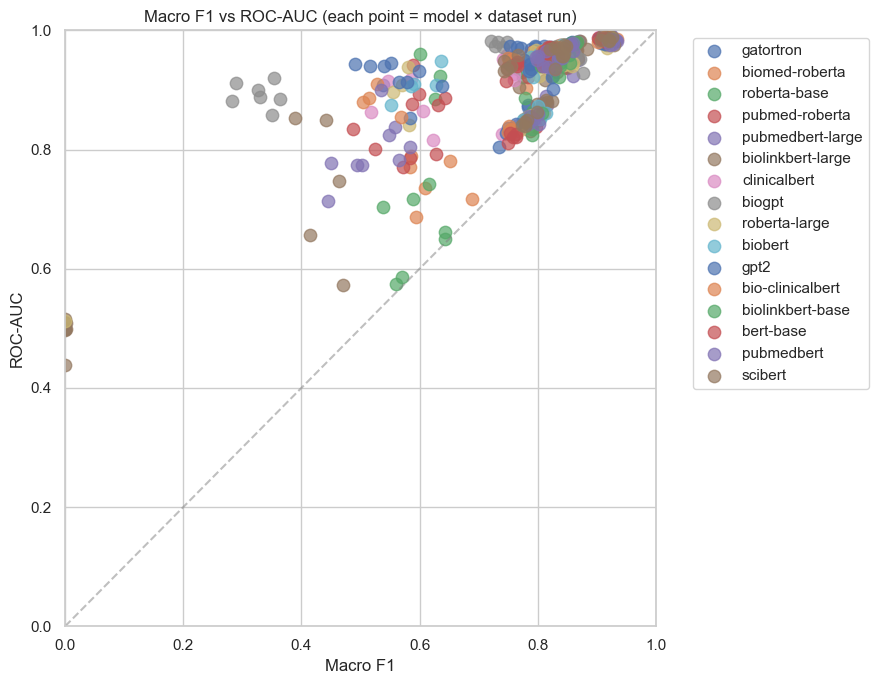

In [5]:
df_auc = df.dropna(subset=["auc", "macro_f1"])

fig, ax = plt.subplots(figsize=(9, 7))
for model in df_auc["model"].unique():
    subset = df_auc[df_auc["model"] == model]
    ax.scatter(subset["macro_f1"], subset["auc"], label=model, s=80, alpha=0.7)

ax.plot([0, 1], [0, 1], "--", color="gray", alpha=0.5)
ax.set_xlabel("Macro F1")
ax.set_ylabel("ROC-AUC")
ax.set_title("Macro F1 vs ROC-AUC (each point = model × dataset run)")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig("macro_f1_vs_auc.png", dpi=150)
plt.show()

## 5. Micro F1 vs Macro F1

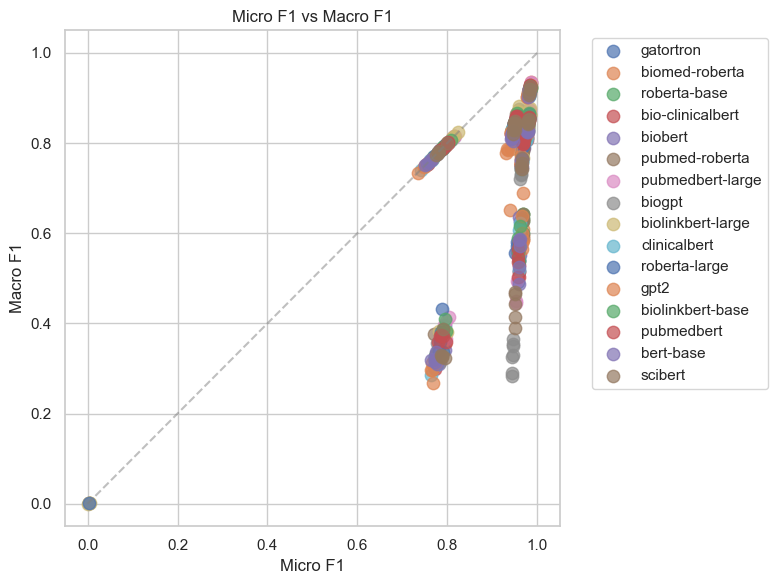

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))
for model in df["model"].unique():
    subset = df[df["model"] == model]
    ax.scatter(subset["micro_f1"], subset["macro_f1"], label=model, s=80, alpha=0.7)

ax.plot([0, 1], [0, 1], "--", color="gray", alpha=0.5)
ax.set_xlabel("Micro F1")
ax.set_ylabel("Macro F1")
ax.set_title("Micro F1 vs Macro F1")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig("micro_vs_macro_f1.png", dpi=150)
plt.show()

## 6. Best Model per Dataset (by ROC-AUC)

In [7]:
best_rows = []
for dataset in sorted(df["dataset"].unique()):
    subset = df[df["dataset"] == dataset].dropna(subset=["auc"])
    if subset.empty:
        continue
    means = subset.groupby("model").agg({
        "micro_f1": "mean",
        "macro_f1": "mean",
        "auc": "mean",
    })
    best = means.sort_values("auc", ascending=False).head(1).reset_index()
    best.insert(0, "dataset", dataset)
    best_rows.append(best)

best_df = pd.concat(best_rows, ignore_index=True) if best_rows else pd.DataFrame()
best_df.round(3)

,dataset,model,micro_f1,macro_f1,auc
0,bc5cdr,gatortron,0.953,0.857,0.979
1,chemprot,biogpt,0.964,0.734,0.978
2,ddi,gatortron,0.984,0.921,0.989
3,drugprot,gatortron,0.958,0.527,0.936
4,euadr,biobert,0.950,0.824,0.966
5,gad,biolinkbert-large,0.811,0.811,0.877


## 7. Average Rank Across Datasets

Aggregate model performance across all datasets by ranking models within each dataset and averaging.

In [8]:
rank_metrics = ["micro_f1", "macro_f1", "auc"]
rank_df = (
    df.groupby(["model", "dataset"])[rank_metrics].mean().reset_index()
)

ranks = (
    rank_df.set_index(["dataset", "model"])[rank_metrics]
    .groupby(level="dataset")
    .rank(ascending=False, method="min")
)
avg_ranks = ranks.groupby(level="model").mean().sort_values("auc")

print("Average rank across datasets (lower = better):")
avg_ranks.round(2)

Average rank across datasets (lower = better):


,micro_f1,macro_f1,auc
model,,,
gatortron,5.38,5.50,1.67
biobert,6.50,7.25,5.67
biogpt,10.38,10.88,6.83
pubmedbert-large,3.75,3.62,7.00
scibert,9.00,10.25,8.00
bio-clinicalbert,13.00,13.50,8.33
biomed-roberta,6.75,6.38,8.67
roberta-large,8.00,7.25,8.67
pubmed-roberta,8.12,7.38,9.17


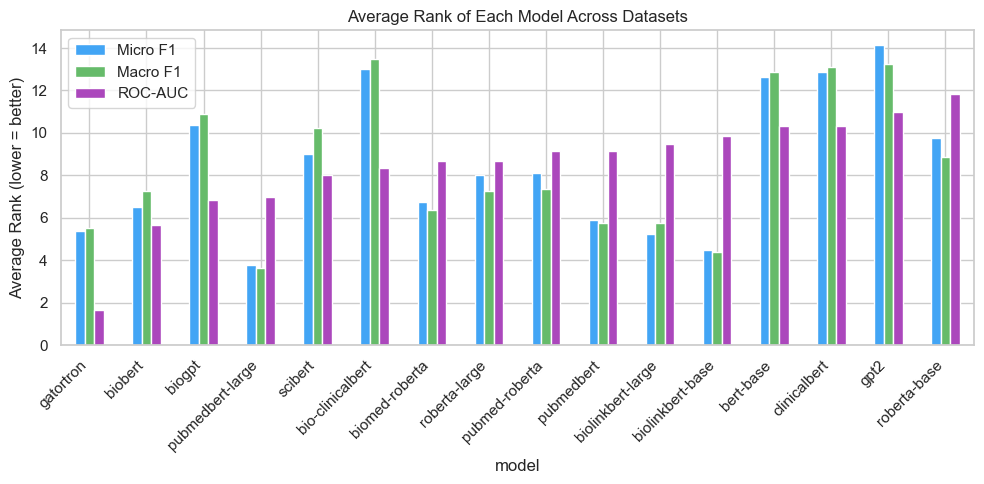

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
avg_ranks.plot(kind="bar", ax=ax, color=["#42A5F5", "#66BB6A", "#AB47BC"])
ax.set_ylabel("Average Rank (lower = better)")
ax.set_title("Average Rank of Each Model Across Datasets")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.legend(["Micro F1", "Macro F1", "ROC-AUC"], loc="best")
plt.tight_layout()
plt.savefig("avg_rank.png", dpi=150)
plt.show()